In [1]:
import pandas as pd

data = [
    ["1step_0shot", 0.85, 0.0, 0.3556, 1.0, 0.0260, 0.3308],
    ["1step_10shot",0.90, 0.0, 0.3508, 1.0, 0.0207, 0.3378],
    ["1step_5shot", 0.90, 0.0, 0.5330, 1.0, 0.0156, 0.3168],
    ["2step_0shot", 0.80, 0.0, 0.5711, 1.0, 0.0103, 0.3472],
    ["2step_10shot",0.90, 0.0, 0.3431, 1.0, 0.0228, 0.3412],
    ["2step_5shot", 0.95, 0.0, 0.3643, 1.0, 0.0191, 0.3311],
    ["Baseline",    0.90, 0.0, 0.2905, 1.0, 0.0201, 0.4058],
]

columns = ["Setting","Val ↑","Ove ↓","Ali ↓","Uti ↑","Occ ↓","Rea ↓"]

table = pd.DataFrame(data, columns=columns)
table

,Setting,Val ↑,Ove ↓,Ali ↓,Uti ↑,Occ ↓,Rea ↓
0,1step_0shot,0.85,0.0,0.3556,1.0,0.0260,0.3308
1,1step_10shot,0.90,0.0,0.3508,1.0,0.0207,0.3378
2,1step_5shot,0.90,0.0,0.5330,1.0,0.0156,0.3168
3,2step_0shot,0.80,0.0,0.5711,1.0,0.0103,0.3472
4,2step_10shot,0.90,0.0,0.3431,1.0,0.0228,0.3412
5,2step_5shot,0.95,0.0,0.3643,1.0,0.0191,0.3311
6,Baseline,0.90,0.0,0.2905,1.0,0.0201,0.4058


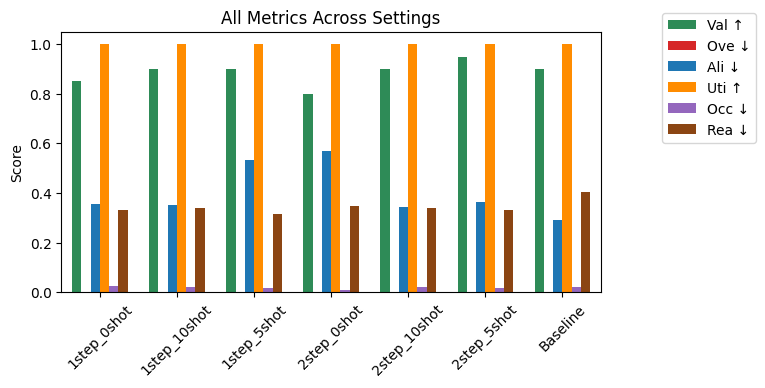

In [2]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    "Val ↑": "#2E8B57", #Green
    "Ove ↓": "#D62728", #Red
    "Ali ↓": "#1F77B4", #Blue
    "Uti ↑": "#FF8C00", #Orange
    "Occ ↓": "#9467BD", #Purple
    "Rea ↓": "#8B4513" #Brown
}

def plot_bar_all_metrics(table):

    metrics = list(COLORS.keys())
    settings = table["Setting"]

    x = np.arange(len(settings))
    width = 0.12

    plt.figure(figsize=(8,4))

    offset = (len(metrics) - 1) / 2 * width

    for i, metric in enumerate(metrics):
        plt.bar(x + i*width - offset, table[metric], width,
                label=metric, color=COLORS[metric])

    plt.xticks(x, settings, rotation=45)
    plt.xlim(-0.5, len(settings) - 0.5)
    
    plt.ylabel("Score")
    plt.title("All Metrics Across Settings")
    plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.show()

plot_bar_all_metrics(table)

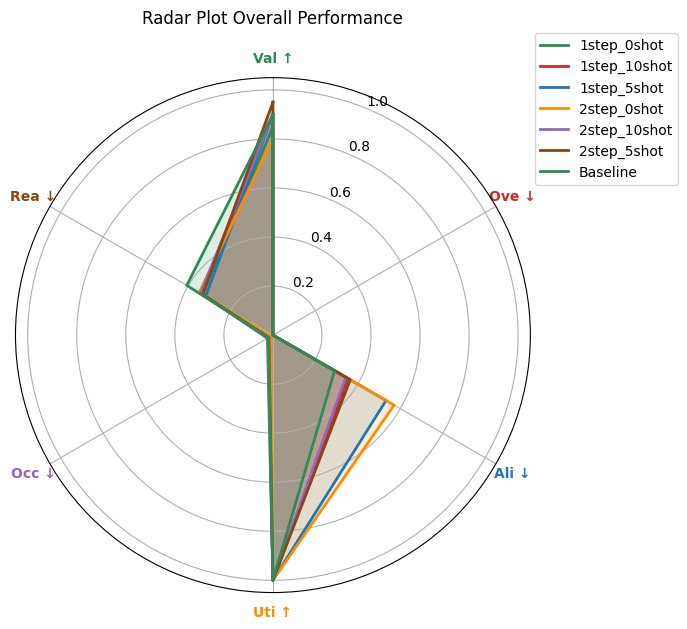

In [3]:
#Radar Plot
def plot_radar(table):

    metrics = list(COLORS.keys())

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    color_list = list(COLORS.values())

    for idx, row in table.iterrows():
        values = row[metrics].values.tolist()
        values += [values[0]]

        color = color_list[idx % len(color_list)]

        ax.plot(angles, values, linewidth=2, label=row["Setting"], color=color)
        ax.fill(angles, values, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    # Metric-based label coloring
    for label, color in zip(ax.get_xticklabels(), COLORS.values()):
        label.set_color(color)
        label.set_fontweight("bold")

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_title("Radar Plot Overall Performance", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

plot_radar(table)

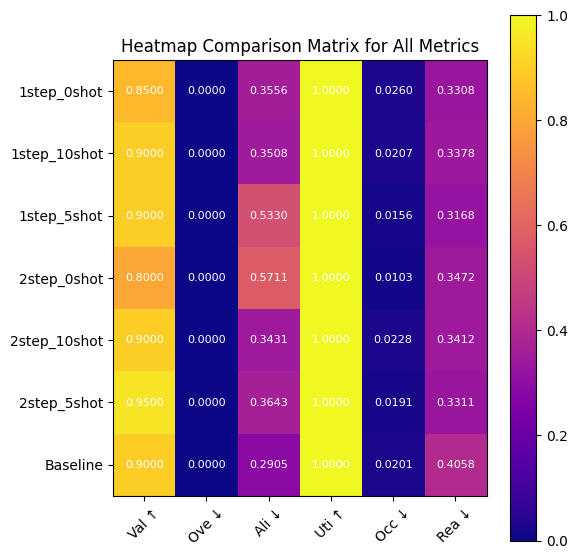

In [4]:
#Heatmap
def plot_heatmap(table):

    data = table.set_index("Setting")

    plt.figure(figsize=(6,6))
    im = plt.imshow(data.values, cmap="plasma")

    plt.xticks(range(len(data.columns)), data.columns, rotation=45)
    plt.yticks(range(len(data.index)), data.index)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            plt.text(
                j, i,
                f"{data.values[i, j]:.4f}",
                ha="center",
                va="center",
                color="white",
                fontsize=8
            )

    plt.title("Heatmap Comparison Matrix for All Metrics")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
plot_heatmap(table)

In [5]:
import pandas as pd

data = [
    ["0_1step_0shot", 0.75, 0.0, 0.2946, 1.0, 0.0898, 0.3563],
    ["0_1step_10shot", 0.75, 0.0, 0.2946, 1.0, 0.0834, 0.3563],
    ["0_1step_5shot", 0.55, 0.0, 0.2075, 1.0, 0.0548, 0.3065],
    ["0_2step_0shot", 0.75, 0.0, 0.3671, 1.0, 0.0146, 0.2553],
    ["0_2step_10shot", 0.75, 0.0, 0.3279, 1.0, 0.1006, 0.3148],
    ["0_2step_5shot", 0.75, 0.0, 0.2946, 1.0, 0.0825, 0.3563],
    ["Baseline",  0.95, 0.0, 0.2947, 1.0, 0.0645, 0.3243],
]

columns = ["Setting","Val ↑","Ove ↓","Ali ↓","Uti ↑","Occ ↓","Rea ↓"]

table = pd.DataFrame(data, columns=columns)
table

,Setting,Val ↑,Ove ↓,Ali ↓,Uti ↑,Occ ↓,Rea ↓
0,0_1step_0shot,0.75,0.0,0.2946,1.0,0.0898,0.3563
1,0_1step_10shot,0.75,0.0,0.2946,1.0,0.0834,0.3563
2,0_1step_5shot,0.55,0.0,0.2075,1.0,0.0548,0.3065
3,0_2step_0shot,0.75,0.0,0.3671,1.0,0.0146,0.2553
4,0_2step_10shot,0.75,0.0,0.3279,1.0,0.1006,0.3148
5,0_2step_5shot,0.75,0.0,0.2946,1.0,0.0825,0.3563
6,Baseline,0.95,0.0,0.2947,1.0,0.0645,0.3243


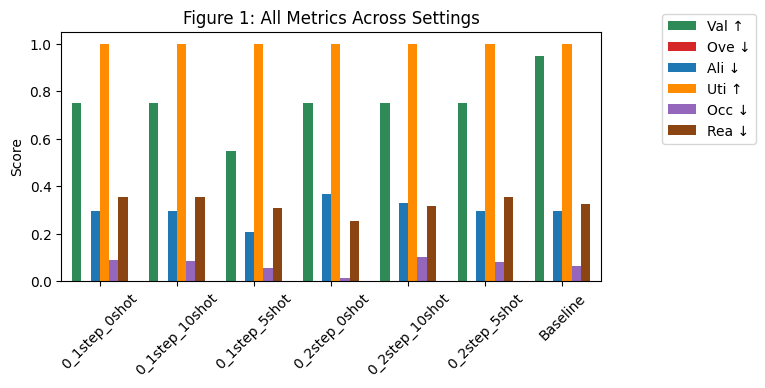

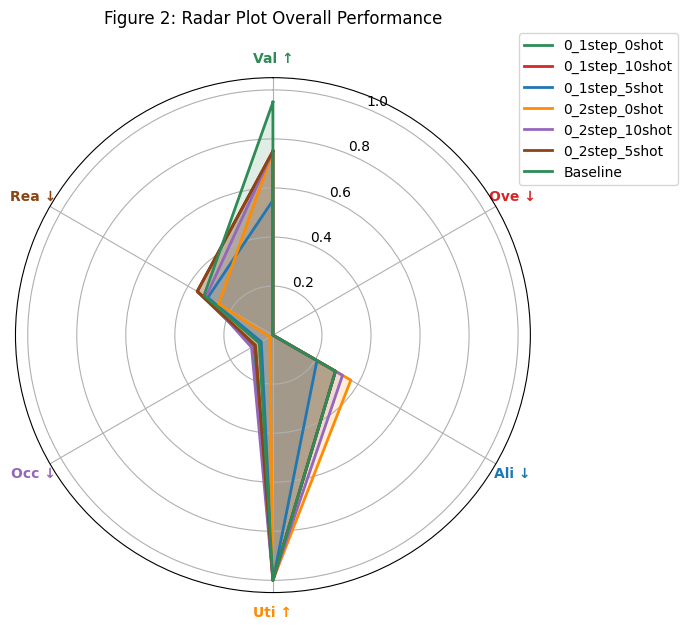

In [6]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    "Val ↑": "#2E8B57", #Green
    "Ove ↓": "#D62728", #Red
    "Ali ↓": "#1F77B4", #Blue
    "Uti ↑": "#FF8C00", #Orange
    "Occ ↓": "#9467BD", #Purple
    "Rea ↓": "#8B4513" #Brown
}

def plot_bar_all_metrics(table):

    metrics = list(COLORS.keys())
    settings = table["Setting"]

    x = np.arange(len(settings))
    width = 0.12

    plt.figure(figsize=(8,4))

    offset = (len(metrics) - 1) / 2 * width

    for i, metric in enumerate(metrics):
        plt.bar(x + i*width - offset, table[metric], width,
                label=metric, color=COLORS[metric])

    plt.xticks(x, settings, rotation=45)
    plt.xlim(-0.5, len(settings) - 0.5)
    
    plt.ylabel("Score")
    plt.title("Figure 1: All Metrics Across Settings")
    plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.show()

#Radar Plot
def plot_radar(table):

    metrics = list(COLORS.keys())

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    color_list = list(COLORS.values())

    for idx, row in table.iterrows():
        values = row[metrics].values.tolist()
        values += [values[0]]

        color = color_list[idx % len(color_list)]

        ax.plot(angles, values, linewidth=2, label=row["Setting"], color=color)
        ax.fill(angles, values, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    # Metric-based label coloring
    for label, color in zip(ax.get_xticklabels(), COLORS.values()):
        label.set_color(color)
        label.set_fontweight("bold")

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_title("Figure 2: Radar Plot Overall Performance", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

plot_bar_all_metrics(table)
plot_radar(table)


Poster       IoU    Overlap  Alignment Dist    Validity Occlusion Readability Utility
Badminton    0.064   0.450   0.700   0.756   1.0     0.064   0.150   0.652
Book         0.000   0.000   0.975   0.687   1.0     0.000   0.578   0.810
Jaggery      0.117   0.429   0.775   0.790   1.0     0.117   0.262   0.707
Cricket Bat  0.000   0.000   0.625   0.682   1.0     0.000   0.473   0.695
Skateboard   0.000   0.000   0.950   0.686   1.0     0.000   0.525   0.790


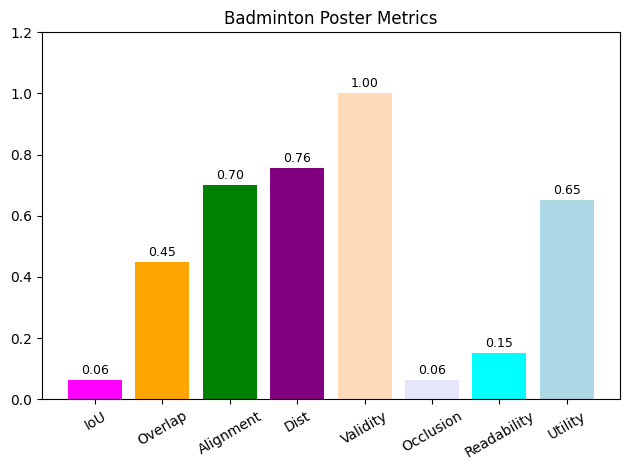

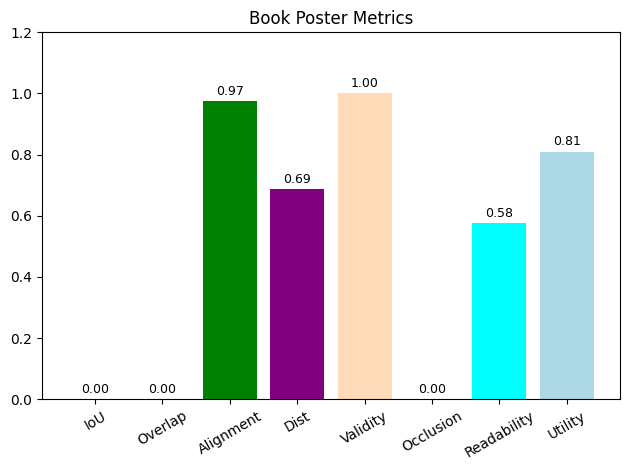

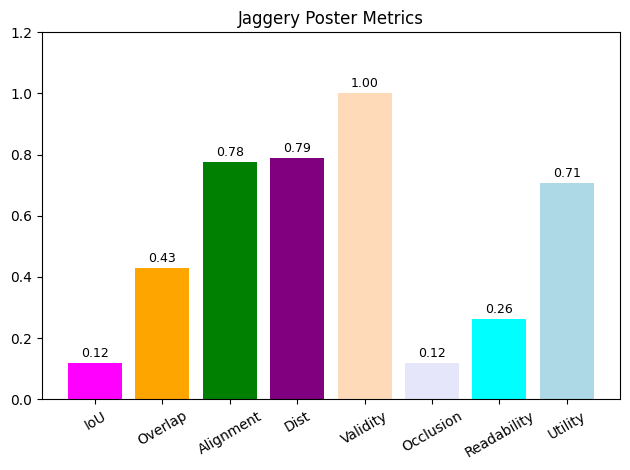

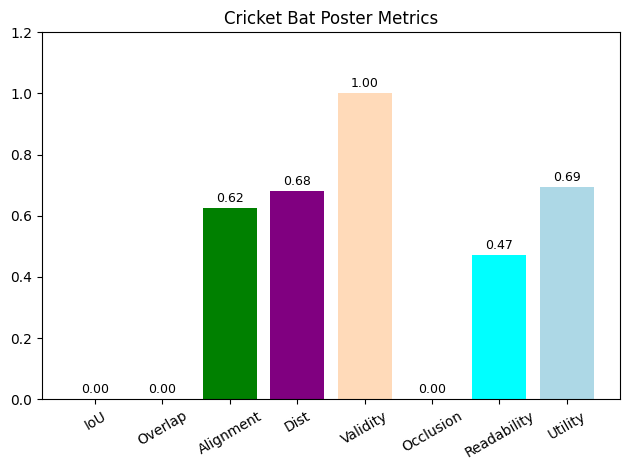

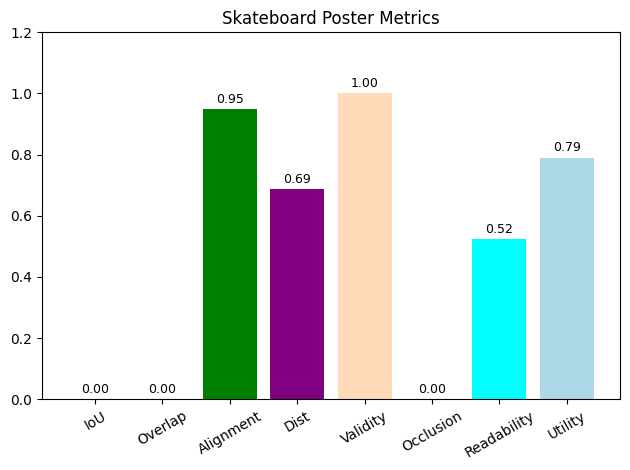

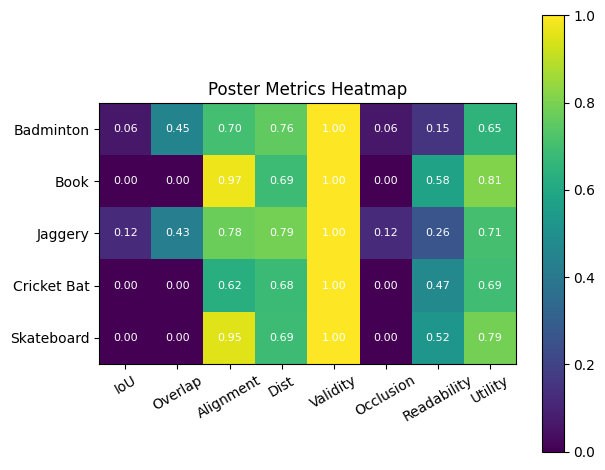

In [7]:
import numpy as np
import matplotlib.pyplot as plt

IMG_W, IMG_H = 800, 1000

# -----------------------------
# CONVERT % → PIXELS
# -----------------------------
def to_pixels(b):
    return (
        b["x_start"] / 100 * IMG_W,
        b["y_start"] / 100 * IMG_H,
        b["x_end"] / 100 * IMG_W,
        b["y_end"] / 100 * IMG_H,
    )

# -----------------------------
# METRICS
# -----------------------------
def area(box):
    return max(0, box[2] - box[0]) * max(0, box[3] - box[1])

def compute_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    union = area(a) + area(b) - inter

    return inter / union if union > 0 else 0


def overlap_ratio(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    return inter / min(area(a), area(b)) if min(area(a), area(b)) > 0 else 0


def alignment_score(a, b):
    cx_a = (a[0] + a[2]) / 2
    cx_b = (b[0] + b[2]) / 2
    return 1 - abs(cx_a - cx_b) / IMG_W


def distance_score(a, b):
    cx_a = (a[0] + a[2]) / 2
    cy_a = (a[1] + a[3]) / 2
    cx_b = (b[0] + b[2]) / 2
    cy_b = (b[1] + b[3]) / 2

    dist = np.sqrt((cx_a - cx_b)**2 + (cy_a - cy_b)**2)
    max_dist = np.sqrt(IMG_W**2 + IMG_H**2)

    return 1 - dist / max_dist


def validity(iou):
    return 1 if iou < 0.2 else 0


def occlusion(iou):
    return iou


def readability(text_box):
    # scaled for better interpretability
    return min(area(text_box) / (IMG_W * IMG_H) * 3, 1)


def utility(valid, align, read, dist):
    return (valid + align + read + dist) / 4


# -----------------------------
# POSTER DEFINITIONS (REALISTIC)
# -----------------------------
posters = {
    "Badminton": {
        "product": {"x_start": 20, "x_end": 85, "y_start": 35, "y_end": 85},
        "text": {"x_start": 70, "x_end": 95, "y_start": 30, "y_end": 50},
    },
    "Book": {
        "product": {"x_start": 30, "x_end": 70, "y_start": 10, "y_end": 45},
        "text": {"x_start": 25, "x_end": 80, "y_start": 50, "y_end": 85},
    },
    "Jaggery": {
        "product": {"x_start": 25, "x_end": 85, "y_start": 45, "y_end": 90},
        "text": {"x_start": 60, "x_end": 95, "y_start": 35, "y_end": 60},
    },
    "Cricket Bat": {
        "product": {"x_start": 55, "x_end": 85, "y_start": 10, "y_end": 90},
        "text": {"x_start": 10, "x_end": 55, "y_start": 60, "y_end": 95},
    },
    "Skateboard": {
        "product": {"x_start": 30, "x_end": 80, "y_start": 15, "y_end": 50},
        "text": {"x_start": 25, "x_end": 75, "y_start": 55, "y_end": 90},
    },
}

# -----------------------------
# EVALUATION
# -----------------------------
results = {}

for name, data in posters.items():
    p = to_pixels(data["product"])
    t = to_pixels(data["text"])

    iou = compute_iou(p, t)
    overlap = overlap_ratio(p, t)
    align = alignment_score(p, t)
    dist = distance_score(p, t)
    valid = validity(iou)
    occ = occlusion(iou)
    read = readability(t)
    util = utility(valid, align, read, dist)

    results[name] = [iou, overlap, align, dist, valid, occ, read, util]

# -----------------------------
# PRINT TABLE
# -----------------------------
headers = ["Poster", "IoU", "Overlap", "Alignment", "Dist", "Validity", "Occlusion", "Readability", "Utility"]

print("\n" + "="*110)
print("{:<12} {:<6} {:<8} {:<7} {:<7} {:<7} {:<7} {:<7} {:<7}".format(*headers))
print("="*110)

for name, vals in results.items():
    print("{:<12} {:.3f}   {:.3f}   {:.3f}   {:.3f}   {:.1f}     {:.3f}   {:.3f}   {:.3f}".format(
        name, *vals
    ))

print("="*110)

# -----------------------------
# BAR CHART (COLORED)
# -----------------------------
labels = ["IoU", "Overlap", "Alignment", "Dist", "Validity", "Occlusion", "Readability", "Utility"]
colors = ['magenta','orange','green','purple','peachpuff','lavender','cyan','lightblue']

for name, values in results.items():
    plt.figure()
    bars = plt.bar(labels, values, color=colors)

    # ADD VALUE LABELS
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.2f}",
            ha='center',
            fontsize=9
        )

    plt.title(f"{name} Poster Metrics")
    plt.xticks(rotation=30)
    plt.ylim(0, 1.2)  # gives space for labels
    plt.tight_layout()
    plt.show()

# -----------------------------
# HEATMAP
# -----------------------------
data = np.array(list(results.values()))

plt.figure()
plt.imshow(data, cmap='viridis')

plt.xticks(range(len(labels)), labels, rotation=30)
plt.yticks(range(len(results)), list(results.keys()))

# ADD NUMBERS INSIDE CELLS
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i, j]:.2f}",
                 ha="center", va="center", color="white", fontsize=8)

plt.colorbar()
plt.title("Poster Metrics Heatmap")
plt.tight_layout()
plt.show()
